In [53]:
# Paso 0: Imports generales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

plt.style.use('seaborn-v0_8')


In [54]:
# Paso 1: Generar y Cargar dataset (auto-mpg.data / auto-mpg.csv)

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'

column_names = [
    'mpg',
    'cylinders',
    'displacement',
    'horsepower',
    'weight',
    'acceleration',
    'model_year',
    'origin',
    'car_name',
]

auto = pd.read_csv(
    url,
    names=column_names,
    na_values='?',
    comment='\t',
    sep=' ',
    skipinitialspace=True,
)

auto.to_csv('auto-mpg.csv', index=False)

auto.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,NaN
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,NaN
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,NaN
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,NaN
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,NaN


In [55]:
# Paso 2: Inspeccionar variables y limpiar valores faltantes

print('INFO DEL DATASET:')
print(auto.info(), '\n')

print('VALORES FALTANTES POR COLUMNA:')
print(auto.isna().sum(), '\n')

auto_simple = auto[['mpg', 'weight']].dropna()

print('DESPUES DE QUEDARNOS SOLO CON mpg Y weight Y DE ELIMINAR NaN:')
print(auto_simple.info(), '\n')

auto_simple.head()


INFO DEL DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      0 non-null      float64
dtypes: float64(6), int64(3)
memory usage: 28.1 KB
None 

VALORES FALTANTES POR COLUMNA:
mpg               0
cylinders         0
displacement      0
horsepower        6
weight            0
acceleration      0
model_year        0
origin            0
car_name        398
dtype: int64 

DESPUES DE QUEDARNOS SOLO CON mpg Y weight Y DE ELIMINAR NaN:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entri

,mpg,weight
0,18.0,3504.0
1,15.0,3693.0
2,18.0,3436.0
3,16.0,3433.0
4,17.0,3449.0


In [56]:
# Paso 2b: Convertir a unidades metricas (kg y L/100 km)

# peso en kilogramos (1 lb = 0.45359237 kg)
auto_simple['weight_kg'] = auto_simple['weight'] * 0.45359237

# consumo en litros/100 km (L/100km = 235.214583 / mpg)
auto_simple['consumo_l_100km'] = 235.214583 / auto_simple['mpg']

auto_simple[['mpg', 'consumo_l_100km', 'weight', 'weight_kg']].head()


,mpg,consumo_l_100km,weight,weight_kg
0,18.0,13.067477,3504.0,1589.387664
1,15.0,15.680972,3693.0,1675.116622
2,18.0,13.067477,3436.0,1558.543383
3,16.0,14.700911,3433.0,1557.182606
4,17.0,13.836152,3449.0,1564.440084


In [57]:
# Paso 3: Definir X (peso en kg) e y (consumo en L/100 km)

X = auto_simple[['weight_kg']]
y = auto_simple['consumo_l_100km']

print('Ejemplo X (weight_kg):')
print(X.head(), '\n')

print('Ejemplo y (consumo_l_100km):')
print(y.head())


Ejemplo X (weight_kg):
     weight_kg
0  1589.387664
1  1675.116622
2  1558.543383
3  1557.182606
4  1564.440084 

Ejemplo y (consumo_l_100km):
0    13.067477
1    15.680972
2    13.067477
3    14.700911
4    13.836152
Name: consumo_l_100km, dtype: float64


In [58]:
# Paso 4: Separar en train y test (80/20)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)

print('Tamano X_train:', X_train.shape)
print('Tamano X_test :', X_test.shape)
print('Tamano y_train:', y_train.shape)
print('Tamano y_test :', y_test.shape)


Tamano X_train: (318, 1)
Tamano X_test : (80, 1)
Tamano y_train: (318,)
Tamano y_test : (80,)


In [59]:
# Paso 5: Entrenar con LinearRegression (unidades metricas)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

coef = lin_reg.coef_[0]  # pendiente
intercept = lin_reg.intercept_  # intercepto

print(f'Intercepto: {intercept:.3f}')
print(f'Coeficiente de peso: {coef:.6f} L/100km por kg')


Intercepto: -0.958
Coeficiente de peso: 0.009017 L/100km por kg


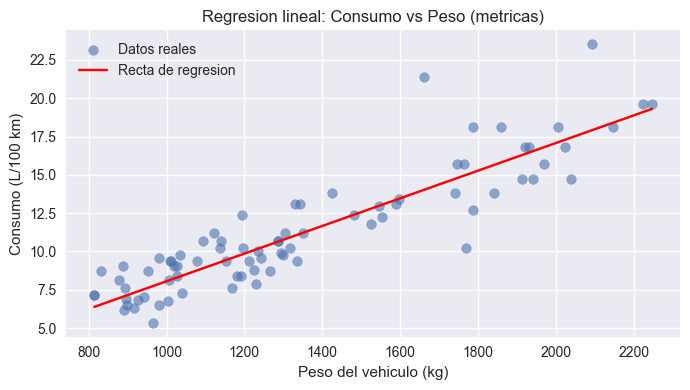

In [60]:
# Paso 6: Visualizar recta de regresion (metricas)

y_pred = lin_reg.predict(X_test)

order = X_test['weight_kg'].argsort()
X_test_sorted = X_test.iloc[order]
y_test_sorted = y_test.iloc[order]
y_pred_sorted = y_pred[order]

plt.figure(figsize=(7, 4))
plt.scatter(X_test_sorted['weight_kg'], y_test_sorted, alpha=0.6, label='Datos reales')
plt.plot(X_test_sorted['weight_kg'], y_pred_sorted, color='red', label='Recta de regresion')
plt.xlabel('Peso del vehiculo (kg)')
plt.ylabel('Consumo (L/100 km)')
plt.title('Regresion lineal: Consumo vs Peso (metricas)')
plt.legend()
plt.tight_layout()
plt.show()


In [61]:
# Paso 7: Evaluar con R2 y MAE

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'R2  (coeficiente de determinacion): {r2:.4f}')
print(f'MAE (error absoluto medio)       : {mae:.4f} L/100km')


R2  (coeficiente de determinacion): 0.8050
MAE (error absoluto medio)       : 1.2491 L/100km


In [62]:
# Paso 8: Interpretar el coeficiente de regresion

print(f'Intercepto: {intercept:.3f}')
print(f'Coeficiente de peso: {coef:.6f} L/100km por kg')

if coef > 0:
    print('Interpretacion: el coeficiente es positivo, por lo que a mayor peso (kg), mayor consumo en L/100 km.')
else:
    print('Interpretacion: el coeficiente es negativo, lo que implicaria que al aumentar el peso, el consumo baja.')

delta_kg = 100
cambio_consumo = coef * delta_kg
print(f'Ejemplo: si aumentamos el peso del auto en {delta_kg} kg, el modelo espera un cambio de {cambio_consumo:.3f} L/100 km.')


Intercepto: -0.958
Coeficiente de peso: 0.009017 L/100km por kg
Interpretacion: el coeficiente es positivo, por lo que a mayor peso (kg), mayor consumo en L/100 km.
Ejemplo: si aumentamos el peso del auto en 100 kg, el modelo espera un cambio de 0.902 L/100 km.


Probar el modelo con ejemplos concretos (predicción manual)

In [63]:
# Probar el modelo con valores concretos de peso (en kg)

def predecir_consumo_por_peso(peso_kg):
    """
    Recibe un peso en kg y devuelve la predicción de consumo en L/100 km.
    """
    # sklearn espera un array 2D: [[peso_kg]]
    X_nuevo = np.array([[peso_kg]])
    consumo_pred = lin_reg.predict(X_nuevo)[0]
    return consumo_pred

# Ejemplos de prueba
pesos_ejemplo = [1000, 1200, 1500, 1800]  # kg

for p in pesos_ejemplo:
    pred = predecir_consumo_por_peso(p)
    print(f"Peso: {p:4d} kg -> consumo estimado: {pred:5.2f} L/100 km")


Peso: 1000 kg -> consumo estimado:  8.06 L/100 km
Peso: 1200 kg -> consumo estimado:  9.86 L/100 km
Peso: 1500 kg -> consumo estimado: 12.57 L/100 km
Peso: 1800 kg -> consumo estimado: 15.27 L/100 km


d:\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
d:\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
d:\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
d:\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Comparar predicción vs dato real de un auto del dataset

In [64]:
# Elegir un índice cualquiera del conjunto de test
idx = 0  # cambia este número para probar otros autos

peso_real = X_test.iloc[idx]["weight_kg"]
consumo_real = y_test.iloc[idx]

# Convertir a la forma que espera sklearn (2D)
consumo_pred = lin_reg.predict([[peso_real]])[0]

print(f"Peso del auto: {peso_real:.1f} kg")
print(f"Consumo real : {consumo_real:.2f} L/100 km")
print(f"Consumo pred.: {consumo_pred:.2f} L/100 km")
print(f"Error        : {abs(consumo_real - consumo_pred):.2f} L/100 km")


Peso del auto: 814.2 kg
Consumo real : 7.13 L/100 km
Consumo pred.: 6.38 L/100 km
Error        : 0.74 L/100 km


d:\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Probar con inputs desde teclado (interactivo)

In [65]:
# Probar ingresando el peso por teclado

peso_str = input("Ingresa el peso del auto en kg: ")
peso_kg = float(peso_str)

X_nuevo = np.array([[peso_kg]])
consumo_pred = lin_reg.predict(X_nuevo)[0]

print(f"Para un auto de {peso_kg:.1f} kg, el modelo estima {consumo_pred:.2f} L/100 km.")


Para un auto de 258.0 kg, el modelo estima 1.37 L/100 km.


d:\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Celda para un gráfico interactivo simple (línea + punto)

In [66]:
from ipywidgets import interact, FloatSlider
import numpy as np
import matplotlib.pyplot as plt

# Calculamos R² una vez (modelo ya entrenado)
r2 = r2_score(y_test, y_pred)

min_peso = auto_simple["weight_kg"].min()
max_peso = auto_simple["weight_kg"].max()

def mostrar_prediccion(peso_kg):
    consumo_pred = lin_reg.predict(np.array([[peso_kg]]))[0]

    plt.figure(figsize=(7, 4))
    plt.scatter(
        auto_simple["weight_kg"],
        auto_simple["consumo_l_100km"],
        alpha=0.3,
        label="Datos reales"
    )

    pesos_linea = np.linspace(min_peso, max_peso, 100).reshape(-1, 1)
    consumos_linea = lin_reg.predict(pesos_linea)
    plt.plot(pesos_linea, consumos_linea, color="red", label="Recta de regresión")

    plt.scatter([peso_kg], [consumo_pred], color="black", s=80, label="Predicción")

    plt.xlabel("Peso del vehículo (kg)")
    plt.ylabel("Consumo (L/100 km)")
    plt.title(f"Consumo vs Peso (R² = {r2:.3f})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Peso: {peso_kg:.1f} kg -> consumo estimado: {consumo_pred:.2f} L/100 km")

interact(
    mostrar_prediccion,
    peso_kg=FloatSlider(
        min=min_peso,
        max=max_peso,
        step=50,
        value=(min_peso + max_peso) / 2,
        description="Peso (kg)"
    )
)


interactive(children=(FloatSlider(value=1531.5546373050001, description='Peso (kg)', max=2331.4647818000003, m…

<function __main__.mostrar_prediccion(peso_kg)>